# Orthomosaic — Part 3: Objects + Land Cover

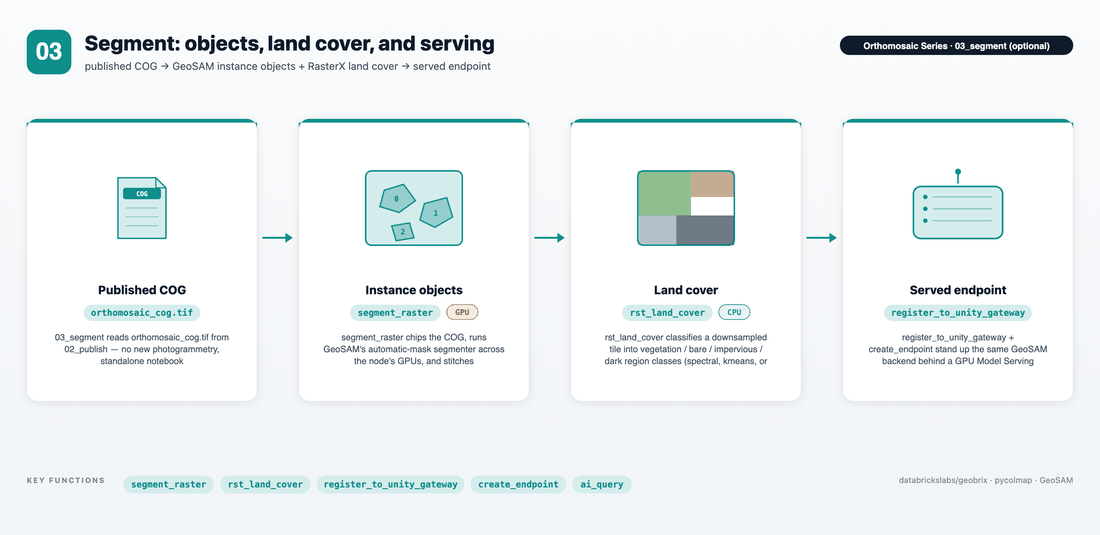

**Turn `02_publish`'s orthomosaic COG into georeferenced *objects* AND a *land-cover map* —
end to end with GeoBrix.**

This capstone runs no new photogrammetry: it reads the COG the series already published and
derives two complementary views of it, then serves the model:

1. **Instance objects** — GeoSAM segments discrete objects (`gbx.models` `segment_raster`),
   fanned across the node's GPU(s); one polygon per detected object.
2. **Land cover** — `rst_land_cover` classifies the scene into contiguous region classes
   (vegetation / bare / impervious / dark), `spectral` vs `kmeans`, composed from the `rst_*`
   family — entirely on CPU.
3. **Served endpoint (Unity Gateway)** — the same GeoSAM backend wrapped as an MLflow pyfunc,
   registered to Unity Catalog and served behind a GPU Model Serving endpoint.

> **Prerequisite.** `02_publish` must have written the orthomosaic COG
> (`orthomosaic_cog.tif`) to its output directory.

> **Runtime.** The **instance-objects** section needs a **GPU cluster** — the Serverless
> **GPU AI Runtime** (environment 5) or a classic GPU node (GeoSAM's SAM backbone is
> CUDA-bound). **Land cover** and the serving/registration calls are CPU / API only.

---

**Last Update:** September 30, 2026

## Setup


In [ ]:
# Install GeoBrix (GeoSAM GPU deps) for INTERACTIVE runs. Job runs strip %pip and inject
# deps from the environment spec instead (--extras models_gpu_env5 --env-version 5
# --wheel <staged>) -- interactive-only; this cell only affects interactive attach.
%pip install --quiet --disable-pip-version-check --no-deps --force-reinstall "geobrix[light_env5,models_gpu_env5,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"
%pip install --quiet "geobrix[light_env5,models_gpu_env5,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"
dbutils.library.restartPython()

## Configuration


In [ ]:
CATALOG_NAME = "geospatial_docs"
SCHEMA_NAME  = "gopro"

# The published orthomosaic COG from 02_publish, for the series' default group
# ("all" -- config_nb's constant GROUP_KEY_COL="_group" case). Mirrors config_nb's
# group_paths()["cog"] output convention for that default single-group run; update
# this path if that convention or the default group key changes.
#
# This notebook is standalone (no %run ./config_nb) for thinness / dependency
# weight, not because of an extras conflict -- config_nb's SfM / dense-MVS /
# GitHub-download machinery (and the `photogrammetry` pycolmap-GPU install that
# comes with it) is unneeded here: nb3 only needs models_gpu_env5, and pulling the
# full photogrammetry wheel just to reuse three constants would be wasteful.
GROUP          = "all"
OUTPUT_DIR     = "/Volumes/geospatial_docs/orthomosaic/data/gopro/outputs/OldOrchard_2017-07-22_result"
ORTHO_COG_PATH = f"{OUTPUT_DIR}/group_{GROUP}/cog/orthomosaic_cog.tif"

# Unity Gateway / GPU serving config -- set PROFILE to your workspace profile.
PROFILE       = "oauth-fe"
MODEL_NAME    = f"{CATALOG_NAME}.{SCHEMA_NAME}.geosam"
ENDPOINT_NAME = "geosam-ortho-endpoint"

# Stand up the LIVE GPU Model Serving endpoint (create_endpoint) and query it?
# Left False by default: segmentation and Unity Catalog registration below run on any
# GPU session at no serving cost. Set True to ALSO provision a GPU_MEDIUM endpoint
# (real, ongoing cost even with scale_to_zero=True) and query it -- the full upsize demo.
CREATE_ENDPOINT = bool(globals().get("CREATE_ENDPOINT", False))

## Read the ortho COG

`runner.segment_raster` accepts an open `rasterio` dataset, raw bytes, or a plain
file path — no Spark raster reader needed for a driver-side call. Open it once here
to confirm it is the raster we expect.


In [ ]:
import rasterio

with rasterio.open(ORTHO_COG_PATH) as ds:
    print(
        f"Ortho COG: {ds.width}x{ds.height}px, {ds.count} band(s), "
        f"dtype={ds.dtypes[0]}, crs={ds.crs}"
    )

## Segment the orthomosaic with GeoSAM (in-notebook, GPU)

`runner.segment_raster` is the single GeoBrix call: it chips the COG into an
overlapping grid, runs GeoSAM's automatic-mask segmenter across every visible GPU,
vectorizes each tile's label mask with its own true georeferencing, and merges
fragments that straddle a seam into one polygon per real-world object before
dropping anything under `min_area`. `gpus="all"` probes every visible device; pass
`gpus=1` to force single-GPU execution instead (same result set, different fan-out).


In [ ]:
# GeoSAM's SAM backbone is CUDA-bound -- confirm the attached cluster actually has a
# GPU before spending time chipping a large orthomosaic.
from databricks.labs.gbx import pyrx as rx

_infra = rx.gpu_infra()
assert _infra["gpu_count"] >= 1, (
    "This section needs GPU compute (0 CUDA devices on the driver). Run on the "
    "Serverless GPU AI Runtime (environment 5) or a classic GPU cluster."
)
print(
    f"[nb3] GPU: {_infra['gpu_count']}x, {_infra.get('per_gpu_vram_mb', 0) // 1024}GB VRAM "
    f"each (driver {_infra.get('driver', '?')}, CUDA {_infra.get('cuda', '?')})"
)

In [ ]:
from databricks.labs.gbx.models import runner

# One call: chip -> GeoSAM infer (fanned across every visible GPU) -> stitch across
# tile seams via each tile's own georeferencing -> polygonize -> drop < min_area.
# overlap is a PERCENTAGE of tile_px (0-100), not a pixel count -- overlap=6 on
# tile_px=1024 is a ~61px seam. min_area is in SQUARE METERS, measured metrically
# whatever the COG's CRS (geodesic area for a geographic CRS like the EPSG:4326 ortho
# here), so 10.0 drops objects under ~10 m^2 -- tune it to the object scale you want.
polys = runner.segment_raster(
    ORTHO_COG_PATH,
    model="geosam",
    gpus="all",
    tile_px=1024,
    overlap=6,
    min_area=10.0,
)
print(f"GeoSAM segmented {len(polys)} object(s) (automatic-mask mode)")
polys.head()

# Single-GPU variant -- never imports torch.cuda probing, forces exactly one device
# slot (same result set, different fan-out):
# polys = runner.segment_raster(ORTHO_COG_PATH, model="geosam", gpus=1)

### Preview: segmented objects over the orthomosaic


In [ ]:
import geopandas as gpd
import shapely.wkb

from databricks.labs.gbx import vizx as vz

# polys carries WKB geometry in the ortho COG's CRS (EPSG:4326, from segment_raster's
# own georeferencing). Wrap it as a GeoDataFrame so vizx can draw it straight from this
# in-memory result -- no intermediate Spark DataFrame needed for a driver-side preview.
polys_gdf = gpd.GeoDataFrame(
    polys.drop(columns=["geom"]),
    geometry=[shapely.wkb.loads(bytes(g)) for g in polys["geom"]],
    crs=4326,
)

# Automatic-mask GeoSAM is CLASS-AGNOSTIC (instance segmentation): it finds distinct
# objects but assigns no semantic type. Colour each detected object by its instance id
# with a legend so the segments are individually distinguishable over the ortho. A
# non-numeric column makes vizx draw a categorical colour per value with a discrete
# legend; a translucent fill lets the orthomosaic show through. (Semantic object *types*
# -- "building", "tree", ... -- come from the text-prompted path; see the Geospatial
# Models docs.)
polys_gdf["object"] = "object " + polys_gdf["label"].astype(str)

vz.plot_static(
    [
        vz.raster_layer(ORTHO_COG_PATH),
        vz.vector_layer(
            polys_gdf, column="object", cmap="tab20", opacity=0.55, width=0.8
        ),
    ],
    title=f"GeoSAM segmentation — {len(polys_gdf)} object(s)",
    basemap=False,
    legend=True,
)

## Land cover — classify the scene into regions

Instance segmentation above finds discrete **objects**. **Land cover** is the complementary
view: partition the whole scene into contiguous **region** classes — vegetation, bare/soil,
impervious/built, dark/shadow. GeoBrix does this with one columnar raster function,
`rst_land_cover`, composed with the existing `rst_*` family — no bespoke classifier code:

`rst_fromfile` → `rst_resample` (downsample so a single-tile pass fits memory) →
`rst_land_cover` (→ an `int32` class-mask tile) → `gbx_rst_polygonize` → labeled polygons.

`method=` picks the technique; the two are shown side by side below:

| | `spectral` | `kmeans` |
|---|---|---|
| **How** | Per-pixel thresholds on indices (excess-green, brightness) | Clusters pixels by similarity, then labels each cluster by its spectral signature |
| **Strength** | Transparent, reproducible, labeled by construction | Adaptive — finds the scene's own groupings without tuned thresholds |
| **Weakness** | Thresholds are scene/illumination-sensitive | Clusters still need labeling; less interpretable |

`method="hybrid"` (the default) is the pragmatic blend: a k-means partition labeled by the
spectral rules. Watch how the two disagree on the mowed central field (vegetation vs
impervious) — that ambiguity is exactly why comparing them is informative.

> **Scale note.** This classifies a single **downsampled** tile — the right scale for a map
> preview. Full-resolution, tiled fan-out across a large scene (e.g. a whole city) is a
> follow-on: `rst_land_cover` is columnar, so Spark applies it per tile across the grid.

In [ ]:
from pyspark.sql import functions as F
from databricks.labs.gbx.pyrx import functions as prx
from databricks.labs.gbx.pyrx.core.land_cover import DEFAULT_CLASSES
from databricks.labs.gbx.core.crs import area_m2
import geopandas as gpd
import rasterio
import shapely.wkb

prx.register(spark)  # register the gbx_rst_* SQL functions (for gbx_rst_polygonize)

# Tunables: downsample factor (a land-cover map doesn't need full res -- and a single
# rst_land_cover tile must fit worker memory), minimum region area (m^2), de-speckle window (px).
LC_FACTOR, LC_MIN_AREA, LC_SMOOTH = 0.34, 50.0, 4
_lc_crs = rasterio.crs.CRS.from_epsg(4326)

# Intuitive land-cover palette (class name -> color) so the legend reads correctly --
# vegetation green, bare tan, impervious gray, dark navy -- instead of a colormap's
# arbitrary (alphabetical) assignment. Passed to vizx via vector_layer(category_colors=).
LC_COLORS = {
    "vegetation": "#2ca02c",
    "bare": "#c2a878",
    "impervious": "#9a9a9a",
    "dark": "#2c2c54",
}


def land_cover(method):
    # One columnar chain of rst_* functions: read the COG -> downsample -> classify to an
    # int32 class-mask tile -> polygonize -> keep regions >= LC_MIN_AREA m^2 (metric area).
    tiles = spark.range(1).select(
        prx.rst_land_cover(
            prx.rst_resample(prx.rst_fromfile(F.lit(ORTHO_COG_PATH)), LC_FACTOR),
            method=method,
            smooth=LC_SMOOTH,
        ).alias("lc")
    )
    tiles.createOrReplaceTempView("lc_tiles")
    rows = spark.sql(
        "SELECT t.geom_wkb AS g, t.value AS v FROM lc_tiles, "
        "LATERAL gbx_rst_polygonize(lc, 1, 4) t"
    ).collect()
    gdf = gpd.GeoDataFrame(
        {"class": [DEFAULT_CLASSES[int(r["v"])] for r in rows]},  # id -> class name
        geometry=[shapely.wkb.loads(bytes(r["g"])) for r in rows],
        crs=4326,
    )
    return gdf[gdf.geometry.apply(lambda g: area_m2(g, _lc_crs)) >= LC_MIN_AREA].reset_index(
        drop=True
    )


lc_spectral = land_cover("spectral")
lc_kmeans = land_cover("kmeans")
print(f"land cover — spectral: {len(lc_spectral)} regions; k-means: {len(lc_kmeans)} regions")

import matplotlib.pyplot as plt

from databricks.labs.gbx import vizx as vz

fig, axes = plt.subplots(1, 2, figsize=(20, 14))
for ax, gdf, name in [(axes[0], lc_spectral, "spectral"), (axes[1], lc_kmeans, "k-means")]:
    vz.plot_static(
        [
            vz.raster_layer(ORTHO_COG_PATH),
            vz.vector_layer(
                gdf, column="class", category_colors=LC_COLORS, opacity=0.55, width=0.6
            ),
        ],
        title=f"Land cover ({name}) — {len(gdf)} regions",
        basemap=False,
        legend=True,
        ax=ax,
    )

## Upsize: serve GeoSAM behind a Unity Gateway endpoint

The same GeoSAM backend, wrapped once as an MLflow pyfunc and registered to Unity
Catalog ("Unity Gateway"), becomes a queryable GPU Model Serving endpoint — no
notebook attached, no GPU cluster to keep warm between calls (with
`scale_to_zero=True`).

Registration runs unconditionally — it logs the model to Unity Catalog and costs no
serving compute. Because the model is registered under a three-level Unity Catalog name (`MODEL_NAME` = `geospatial_docs.gopro.geosam`, i.e. `<catalog>.<schema>.geosam`), it lands as a first-class, **governed and versioned** Unity Catalog model — not a flat, loose artifact. Each registration adds a NEW version, so `<catalog>.<schema>.geosam` is the durable **entrypoint for managing the model**: browse and compare versions, set an alias (e.g. `@prod`), grant access, and choose which version an endpoint serves. Standing up the **live** endpoint is opt-in: the two cells below are
gated by `CREATE_ENDPOINT` (default `False`), because a GPU Model Serving endpoint
bills real, ongoing cost even with `scale_to_zero=True`. Set `CREATE_ENDPOINT = True`
at the top of the notebook to run the full upsize. `create_endpoint` is
**create-only**: it stands up a new endpoint and is not the call to roll a new model
version onto one that already exists.

In [ ]:
from databricks.labs.gbx.models import serving

# build_geosam_pyfunc's predict() calls runner.segment_raster server-side, so the
# served model always segments with the same logic exercised above.
pyfunc = serving.build_geosam_pyfunc(model_type="vit_h")

model_version = serving.register_to_unity_gateway(pyfunc, MODEL_NAME, profile=PROFILE)
print(f"Registered {MODEL_NAME} version {model_version}")

In [ ]:
if CREATE_ENDPOINT:
    endpoint = serving.create_endpoint(
        MODEL_NAME,
        model_version,
        profile=PROFILE,
        endpoint_name=ENDPOINT_NAME,
        workload_type="GPU_MEDIUM",
        scale_to_zero=True,
    )
    print(f"Endpoint {ENDPOINT_NAME} ready: {endpoint.get('state')}")
else:
    print(
        f"CREATE_ENDPOINT=False -- skipping live GPU endpoint creation. The model is "
        f"registered as {MODEL_NAME} v{model_version}; set CREATE_ENDPOINT=True (top of "
        "notebook) to stand up and query the serving endpoint."
    )

In [ ]:
if CREATE_ENDPOINT:
    import rasterio
    from rasterio.io import MemoryFile
    from rasterio.windows import Window

    # Model Serving's custom-endpoint request limit is 16 MB; base64 inflates the
    # payload ~4/3, so sending the WHOLE published COG can exceed that on a real
    # orthomosaic (this series' own Old Orchard COG is close to the limit already). A
    # production client tiles a large raster and queries per-tile -- crop one
    # representative window here (an ephemeral scratch GeoTIFF, never persisted) and
    # encode only that.
    with rasterio.open(ORTHO_COG_PATH) as src:
        win = Window(0, 0, min(512, src.width), min(512, src.height))
        tile_arr = src.read(window=win)
        tile_kwargs = dict(
            driver="GTiff",
            width=win.width,
            height=win.height,
            count=src.count,
            dtype=src.dtypes[0],
            crs=src.crs,
            transform=src.window_transform(win),
        )

    with MemoryFile() as mf:
        with mf.open(**tile_kwargs) as dst:
            dst.write(tile_arr)
        tile_bytes = mf.read()

    # query() base64-encodes the tile bytes and calls the endpoint with the same
    # single-string-column shape build_geosam_pyfunc's predict() expects.
    result = serving.query(ENDPOINT_NAME, tile_bytes, profile=PROFILE)
    print(result["predictions"]["geojson"][:500], "...")

## Calling the served endpoint — four ways

Once `create_endpoint` above reports `READY`, the endpoint is a standard **Databricks
Model Serving** REST endpoint behind the Unity Gateway — callable from a notebook, an
app, a job, or SQL, with no GeoBrix package and no GPU attached on the calling side. All
four forms below hit the same
`https://<workspace>/serving-endpoints/geosam-ortho-endpoint/invocations` URL with the
same `image_b64` input and get back the same shape:

```json
{"predictions": {"geojson": "{\"type\": \"FeatureCollection\", \"features\": [{\"type\": \"Feature\", \"geometry\": {\"type\": \"Polygon\", \"coordinates\": [[[-121.9744, 36.9744], ...]]}, \"properties\": {\"label\": 0, \"score\": 1.0}}]}"}}
```

`predictions` is a **dict** `{"geojson": ...}`, not a list. The decoded `geojson` value
is a GeoJSON `FeatureCollection` string with one `Polygon` **Feature** per detected
object, carrying `properties.label` (int) and `properties.score` (float).

##### curl

```bash
curl \
  -u token:$DATABRICKS_TOKEN \
  -X POST \
  -H "Content-Type: application/json" \
  -d@data.json \
  https://e2-demo-field-eng.cloud.databricks.com/serving-endpoints/geosam-ortho-endpoint/invocations
```

`data.json` holds the request body, e.g.
`{"dataframe_records": [{"image_b64": "<base64 GeoTIFF tile>"}]}`. The quickest smoke
test for the endpoint, and it works from any language that can shell out to `curl`.

##### Python (JSON)

```python
import os
import requests
import numpy as np
import pandas as pd
import json

def create_tf_serving_json(data):
    return {'inputs': {name: data[name].tolist() for name in data.keys()} if isinstance(data, dict) else data.tolist()}

def score_model(dataset):
    url = 'https://e2-demo-field-eng.cloud.databricks.com/serving-endpoints/geosam-ortho-endpoint/invocations'
    headers = {'Authorization': f'Bearer {os.environ.get("DATABRICKS_TOKEN")}', 'Content-Type': 'application/json'}
    ds_dict = {'dataframe_split': dataset.to_dict(orient='split')} if isinstance(dataset, pd.DataFrame) else create_tf_serving_json(dataset)
    data_json = json.dumps(ds_dict, allow_nan=True)
    response = requests.request(method='POST', headers=headers, url=url, data=data_json)
    if response.status_code != 200:
        raise Exception(f'Request failed with status {response.status_code}, {response.text}')
    return response.json()
```

The `dataframe_split` record shape most services call Model Serving with. GeoBrix wraps
exactly this — base64-encoding the tile and posting the request — as `serving.query(...)`
(used above), so most notebook/job callers reach for that instead of re-deriving this.

##### Python (protobuf)

```python
import os
import requests
import numpy as np
from tritonclient.grpc.service_pb2 import ModelInferRequest, ModelInferResponse  # KServe v2 ModelInferRequest/Response
from tritonclient.utils import np_to_triton_dtype, triton_to_np_dtype  # numpy<->KServe v2 dtype helpers

def create_kserve_request(data):
    tensors = data if isinstance(data, dict) else {'input': data}
    request = ModelInferRequest()
    for name, array in tensors.items():
        array = np.ascontiguousarray(array)
        request.inputs.add(name=name, datatype=np_to_triton_dtype(array.dtype), shape=array.shape)
        request.raw_input_contents.append(array.tobytes())
    return request

def score_model(dataset):
    url = 'https://e2-demo-field-eng.cloud.databricks.com/serving-endpoints/geosam-ortho-endpoint/invocations'
    headers = {'Authorization': f'Bearer {os.environ.get("DATABRICKS_TOKEN")}', 'Content-Type': 'application/x-protobuf'}
    request = create_kserve_request(dataset)
    response = requests.request(method='POST', headers=headers, url=url, data=request.SerializeToString())
    if response.status_code != 200:
        raise Exception(f'Request failed with status {response.status_code}, {response.text}')
    result = ModelInferResponse()
    result.ParseFromString(response.content)
    return {output.name: np.frombuffer(result.raw_output_contents[i], dtype=triton_to_np_dtype(output.datatype)).reshape(output.shape) for i, output in enumerate(result.outputs)}
```

The KServe v2 binary protocol (`application/x-protobuf`) — lower-overhead than JSON for
large tensor payloads.

##### SQL

```sql
SELECT ai_query('geosam-ortho-endpoint',
    request => named_struct('image_b64', <value>))
```

Calls the endpoint inline from SQL or a Lakeflow pipeline via `ai_query` — the columnar,
at-scale path: fan segmentation out over a whole **table** of image tiles with one query,
no notebook or Python client involved.

**Links.** [Databricks Model Serving](https://docs.databricks.com/aws/en/machine-learning/model-serving)
· [`ai_query`](https://docs.databricks.com/aws/en/sql/language-manual/functions/ai_query)
· [Unity Catalog model lifecycle](https://docs.databricks.com/aws/en/machine-learning/manage-model-lifecycle/)
· [GeoBrix Serving reference](https://databrickslabs.github.io/geobrix/docs/models/serving)
for `serving.query`, `register_to_unity_gateway`, `build_geosam_pyfunc`, and
`geosam_signature` used earlier in this notebook.

## In-notebook GPU vs served endpoint — when to use which

| | In-notebook (`runner.segment_raster`) | Served endpoint (Unity Gateway) |
|---|---|---|
| **Latency** | No network hop; bounded by the attached GPU's own throughput. | An extra request/response round trip on top of inference. |
| **Cold start** | None once the cluster/session is up. | `scale_to_zero=True` pays a cold-start penalty (loading the model onto a GPU) on the first request after idling. |
| **Cost** | Billed for the whole time the interactive GPU cluster is attached, whether or not it is segmenting. | `scale_to_zero=True` bills only while actually serving; `scale_to_zero=False` (provisioned) bills continuously for predictable low latency. |
| **Best for** | Exploration, tuning `tile_px` / `overlap` / `min_area`, one-off or batch runs already inside a notebook or job. | Programmatic or production access — other services, jobs, or apps calling GeoSAM without a notebook attached. |

> **Note.** The characterizations above are expected behavior based on the endpoint
> lifecycle (cold start, scale-to-zero billing), not measured benchmarks for this
> specific model or dataset — actual latency and cost depend on the workload type,
> image size, and traffic pattern.


## Steps performed

**Instance objects.** `runner.segment_raster` chipped the published orthomosaic COG, ran
GeoSAM (automatic-mask mode) across every visible GPU, stitched tile-seam fragments via each
tile's own georeferencing, and returned one polygon per detected object — previewed
instance-colored over the ortho with `vizx`.

**Land cover.** `rst_land_cover` (`rst_fromfile` → `rst_resample` → the class-mask tile →
`gbx_rst_polygonize`) classified a downsampled ortho into region classes with both `spectral`
and `kmeans`, filtered to regions ≥ `LC_MIN_AREA` m² via `core.crs.area_m2`, and rendered a
labeled map (color + legend) per method — no bespoke classifier code in the notebook.

**Serving.** The same GeoSAM backend was wrapped as an MLflow pyfunc (`build_geosam_pyfunc`)
and registered to Unity Catalog (`register_to_unity_gateway`). When `CREATE_ENDPOINT=True`, it
was also stood up behind a GPU Model Serving endpoint (`create_endpoint`, `scale_to_zero=True`)
and queried (`serving.query`).

**Deliverable.** A `pandas.DataFrame` of object polygons (`label`, `geom` WKB, `score`);
labeled land-cover `GeoDataFrame`s (`class`, geometry) for spectral and k-means; a `MODEL_NAME`
model version registered in Unity Catalog — and, when `CREATE_ENDPOINT=True`, a queryable
`ENDPOINT_NAME` endpoint serving the same model.